<a href="https://colab.research.google.com/github/dannroldan/Procesos-estocasticos/blob/main/Descomposici%C3%B3n_can%C3%B3nica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cadena de Markov

## 1. Matriz de Transición y Diagrama

Definimos nuestro espacio de estados como $S = \{a, b, c, d, e, f, g\}$ y la matriz de transición de probabilidades en un paso, denotada por $P$, como:

$$P = \begin{pmatrix}
1/4 & 0 & 0 & 0 & 0 & 0 & 3/4 \\
1/8 & 1/8 & 1/4 & 0 & 1/4 & 1/8 & 1/8 \\
0 & 0 & 2/5 & 1/5 & 2/5 & 0 & 0 \\
0 & 0 & 1/2 & 1/2 & 0 & 0 & 0 \\
0 & 0 & 0 & 1/2 & 1/2 & 0 & 0 \\
0 & 1/5 & 0 & 1/5 & 1/5 & 1/5 & 1/5 \\
4/5 & 0 & 0 & 0 & 0 & 0 & 1/5
\end{pmatrix}$$

Vamos a usar la biblioteca `networkx` para visualizar el diagrama de transiciones. Esto para ver las conexiones entre los estados, lo cual es fundamental para identificar las clases que swe comunican.

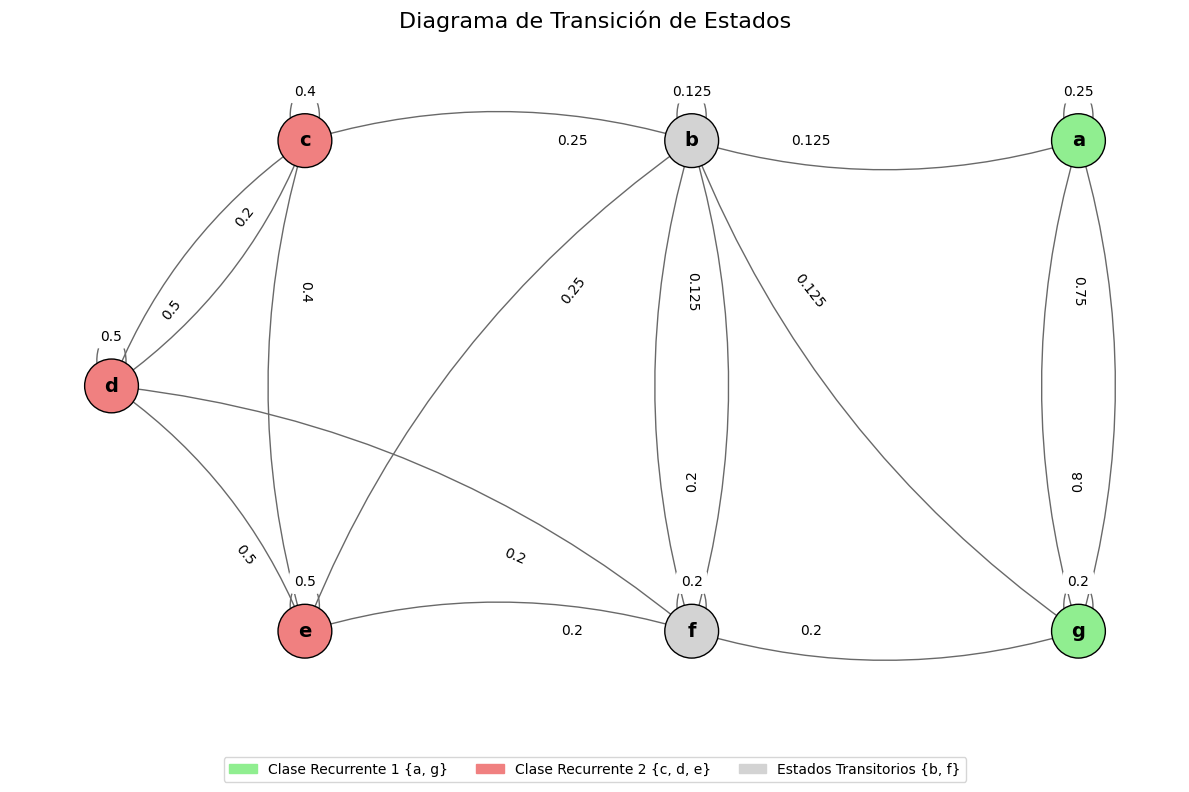

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

estados = ['a', 'b', 'c', 'd', 'e', 'f', 'g']

P = np.array([
    [1/4,   0,   0,   0,   0,   0, 3/4],
    [1/8, 1/8, 1/4,   0, 1/4, 1/8, 1/8],
    [  0,   0, 2/5, 1/5, 2/5,   0,   0],
    [  0,   0, 1/2, 1/2,   0,   0,   0],
    [  0,   0,   0, 1/2, 1/2,   0,   0],
    [  0, 1/5,   0, 1/5, 1/5, 1/5, 1/5],
    [4/5,   0,   0,   0,   0,   0, 1/5]
])

def dibujar_diagrama_mejorado(matriz, estados):
    G = nx.DiGraph()
    n = len(estados)

    for i in range(n):
        for j in range(n):
            if matriz[i, j] > 0:
                G.add_edge(estados[i], estados[j], weight=round(matriz[i, j], 3))

    plt.figure(figsize=(12, 8))


    pos = {
        'a': ( 2,  1), 'g': ( 2, -1),         # clase recurrente 1
        'c': (-2,  1), 'd': (-3,  0), 'e': (-2, -1), # clase rcurrente 2
        'b': ( 0,  1), 'f': ( 0, -1)          # transitorios
    }

    color_map = []
    for node in G:
        if node in ['a', 'g']:
            color_map.append('lightgreen')
        elif node in ['c', 'd', 'e']:
            color_map.append('lightcoral')
        else:
            color_map.append('lightgray')

    nx.draw_networkx_nodes(G, pos, node_size=1500, node_color=color_map, edgecolors='black')
    nx.draw_networkx_labels(G, pos, font_size=14, font_weight='bold')

    nx.draw_networkx_edges(G, pos, edgelist=G.edges(), arrowstyle='-|>',
                           arrowsize=20, connectionstyle='arc3,rad=0.15', edge_color='dimgray')

    edge_labels = nx.get_edge_attributes(G, 'weight')
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, label_pos=0.3, font_size=10)

    patch1 = mpatches.Patch(color='lightgreen', label='Clase Recurrente 1 {a, g}')
    patch2 = mpatches.Patch(color='lightcoral', label='Clase Recurrente 2 {c, d, e}')
    patch3 = mpatches.Patch(color='lightgray', label='Estados Transitorios {b, f}')
    plt.legend(handles=[patch1, patch2, patch3], loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=3)

    plt.title("Diagrama de Transición de Estados", fontsize=16, pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

dibujar_diagrama_mejorado(P, estados)

## 2. Distribución Límite
Para determinar si la matriz tiene una distribución límite, primero analizamos las clases comunicantes del diagrama de transición:

1.  **Clase $C_1 = \{a, g\}$:** Es una clase *cerrada* y *recurrente*. Y la clase es *aperiódica*.
2.  **Clase $C_2 = \{c, d, e\}$:** Es una clase *cerrada* y *recurrente*. Y la clase también es *aperiódica*.
3.  **Estados Transitorios $T = \{b, f\}$:** Desde estos estados es posible alcanzar las clases recurrentes, por lo que son estados *transitorios*.

Como existen *múltiples clases cerradas y recurrentes*, la cadena de Markov **no es irreducible**. Por lo tanto, **no existe una única distribución límite** independiente del estado inicial. Sin embargo, debido a que las clases son aperiódicas, la matriz de potencias $\lim_{n \to \infty} P^n$ sí existe (i.e., el proceso converge), pero las filas de esta matriz límite dependerán del estado inicial (no serán todas iguales).

---

## 3. Descomposición Canónica y Límite de la Potencia $n$-ésima

Para facilitar el análisis, reorganizamos los estados ubicando primero los estados transitorios y luego los de las clases recurrentes. Un nuevo orden de estados es $S' = \{b, f, a, g, c, d, e\}$.
La matriz en forma canónica se expresa como:

$$P_{can} = \begin{pmatrix}
Q & R_1 & R_2 \\
0 & P_1 & 0 \\
0 & 0 & P_2
\end{pmatrix}$$

Donde:
* $Q$ contiene las transiciones entre estados transitorios.
* $P_1$ es la submatriz de transiciones dentro de $C_1$.
* $P_2$ es la submatriz de transiciones dentro de $C_2$.
* $R_1, R_2$ contienen las probabilidades de transición de los estados transitorios hacia $C_1$ y $C_2$ respectivamente.

El límite cuando $n \to \infty$ de esta matriz canónica está dado por:

$$\lim_{n \to \infty} P_{can}^n = \begin{pmatrix}
0 & U \Pi_1 & V \Pi_2 \\
0 & \Pi_1 & 0 \\
0 & 0 & \Pi_2
\end{pmatrix}$$

Aquí, $\Pi_1$ y $\Pi_2$ son las matrices cuyas filas son las distribuciones estacionarias de $P_1$ y $P_2$.
$U$ y $V$ representan las probabilidades de absorción hacia $C_1$ y $C_2$ partiendo de los estados transitorios, calculadas como $A = (I - Q)^{-1} R$, donde $R = [R_1 | R_2]$.

In [11]:
import sympy as sp
import numpy as np

P_sym = sp.Matrix(P).applyfunc(sp.nsimplify)

orden_canonico = [1, 5, 0, 6, 2, 3, 4]
estados_can = [estados[i] for i in orden_canonico]

P_can = P_sym[orden_canonico, orden_canonico]

print("1. Matriz Canónica:")
sp.pprint(P_can)

Q = P_can[0:2, 0:2]  # transitorios
R = P_can[0:2, 2:7]  # R1 y R2 combinados
P1 = P_can[2:4, 2:4] # C1
P2 = P_can[4:7, 4:7] # C2

# calcular distribuciones límite de las submatrices
# P1
eig1 = P1.T.eigenvects()
pi_1 = None
for val, mult, vects in eig1:
    if val == 1:
        pi_1 = vects[0].T
        pi_1 = pi_1 / sum(pi_1)
        break

# P2
eig2 = P2.T.eigenvects()
pi_2 = None
for val, mult, vects in eig2:
    if val == 1:
        pi_2 = vects[0].T
        pi_2 = pi_2 / sum(pi_2)
        break

print("\n2. Distribución estacionaria de P1:")
sp.pprint(pi_1)
print("\n3. Distribución estacionaria de P2:")
sp.pprint(pi_2)

#(I - Q)^-1 * R
I_Q = sp.eye(2) - Q
Matriz_Fundamental = I_Q.inv()
Absorcion = Matriz_Fundamental * R

print("\n4. Probabilidades de absorción:")
sp.pprint(Absorcion)

Pi_lim = sp.zeros(7, 7)

for i in range(2, 4): Pi_lim[i, 2:4] = pi_1
for i in range(4, 7): Pi_lim[i, 4:7] = pi_2

# U * Pi_1
U = Absorcion[:, 0:2]
Pi_lim[0:2, 2:4] = U * sp.Matrix([pi_1, pi_1])

# V * Pi_2
V = Absorcion[:, 2:5]
Pi_lim[0:2, 4:7] = V * sp.Matrix([pi_2, pi_2, pi_2])

print("\n5. Matriz límite de la potencia n-ésima:")
sp.pprint(Pi_lim)

1. Matriz Canónica:
⎡1/8  1/8  1/8  1/8  1/4   0   1/4⎤
⎢                                 ⎥
⎢1/5  1/5   0   1/5   0   1/5  1/5⎥
⎢                                 ⎥
⎢ 0    0   1/4  3/4   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0   4/5  1/5   0    0    0 ⎥
⎢                                 ⎥
⎢ 0    0    0    0   2/5  1/5  2/5⎥
⎢                                 ⎥
⎢ 0    0    0    0   1/2  1/2   0 ⎥
⎢                                 ⎥
⎣ 0    0    0    0    0   1/2  1/2⎦

2. Distribución estacionaria de P1:
⎡16  15⎤
⎢──  ──⎥
⎣31  31⎦

3. Distribución estacionaria de P2:
[1/3  2/5  4/15]

4. Probabilidades de absorción:
⎡4/27  5/27  8/27  1/27  1/3⎤
⎢                           ⎥
⎣1/27  8/27  2/27  7/27  1/3⎦

5. Matriz Límite de la potencia n-ésima:
⎡      16                       ⎤
⎢0  0  ──  5/31  2/9  4/15  8/45⎥
⎢      93                       ⎥
⎢                               ⎥
⎢      16                       ⎥
⎢0  0  ──  5/31  2/9  4/15  8/45⎥
⎢      93                

## 4. Programa gneral para descomposición canónica

Implementamos una función que dada una matriz de transición estocástica y los nombres de sus estados, utiliza `networkx` para:

1.  Identificar todas las clases comunicantes.
2.  Clasificar cada clase en *recurrente* o *transitoria*.
3.  Reordenar los estados para construir y devolver la matriz en su **forma canónica** junto con el nuevo vector de estados.

In [7]:
def obtener_descomposicion_canonica(P_matrix, state_names):
    """
    Dada una matriz de transición y una lista de estados, nos identifica las
    clases recurrentes y transitorias, y devuelve la matriz en forma canónica
    (transitorios primero, luego recurrentes).

    argumentos:
        P_matrix (sympy.Matrix o numpy.ndarray): Matriz de transición P.
        state_names (list): Nombres de los estados.

    outputs:
        tuple: (Matriz Canónica (sympy.Matrix), Nuevo orden de estados (list))
    """
    n = len(state_names)
    G = nx.DiGraph()

    for i in range(n):
        for j in range(n):
            if P_matrix[i, j] > 0:
                G.add_edge(state_names[i], state_names[j])

    scc = list(nx.strongly_connected_components(G))

    clases_recurrentes = []
    estados_transitorios = []

    # clasifica componentes en recurrentes o transitorios
    for componente in scc:
        es_recurrente = True
        for nodo in componente:
            vecinos = list(G.successors(nodo))
            for vecino in vecinos:
                if vecino not in componente:
                    es_recurrente = False
                    break
            if not es_recurrente:
                break

        if es_recurrente:
            # ordenar para mantener consistencia
            clases_recurrentes.extend(sorted(list(componente)))
        else:
            estados_transitorios.extend(sorted(list(componente)))

    nuevo_orden_estados = estados_transitorios + clases_recurrentes

    idx_map = {estado: i for i, estado in enumerate(state_names)}
    indices_nuevos = [idx_map[estado] for estado in nuevo_orden_estados]

    P_sym = sp.Matrix(P_matrix)
    P_canonica = P_sym[indices_nuevos, indices_nuevos]

    return P_canonica, nuevo_orden_estados

P_canonica_gen, estados_can_gen = obtener_descomposicion_canonica(P, estados)

print("Orden de estados identificado por el algoritmo generalizado:")
print(estados_can_gen)

print("\nMatriz en Forma Canónica resultante:")
sp.pprint(P_canonica_gen)

Orden de estados identificado por el algoritmo generalizado:
['b', 'f', 'a', 'g', 'c', 'd', 'e']

Matriz en Forma Canónica resultante:
⎡0.125  0.125  0.125  0.125  0.25  0.0  0.25⎤
⎢                                           ⎥
⎢ 0.2    0.2    0.0    0.2   0.0   0.2  0.2 ⎥
⎢                                           ⎥
⎢ 0.0    0.0   0.25   0.75   0.0   0.0  0.0 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.8    0.2   0.0   0.0  0.0 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.0    0.0   0.4   0.2  0.4 ⎥
⎢                                           ⎥
⎢ 0.0    0.0    0.0    0.0   0.5   0.5  0.0 ⎥
⎢                                           ⎥
⎣ 0.0    0.0    0.0    0.0   0.0   0.5  0.5 ⎦
